<a href="https://colab.research.google.com/github/starsyntaxx/introduction-to-data-cleaning/blob/main/datasets/01_outliers/isolation_method/isolation_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [2]:
X_normal = np.random.normal(loc=0, scale=1, size=(200, 2))

In [3]:
X_outliers = np.array([
    [8, 8],
    [9, 10],
    [-9, -8],
    [10, -10]
])

In [4]:
X = np.vstack([X_normal, X_outliers])

In [5]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.02,   # expected % of anomalies
    random_state=42
)

model.fit(X)

IsolationForest(contamination=0.02, random_state=42)

In [6]:
predictions = model.predict(X)

In [7]:
scores = model.decision_function(X)

In [8]:
anomalies = X[predictions == -1]
print("Detected anomalies:\n", anomalies)

Detected anomalies:
 [[ -3.52890744  -0.94991243]
 [  8.           8.        ]
 [  9.          10.        ]
 [ -9.          -8.        ]
 [ 10.         -10.        ]]


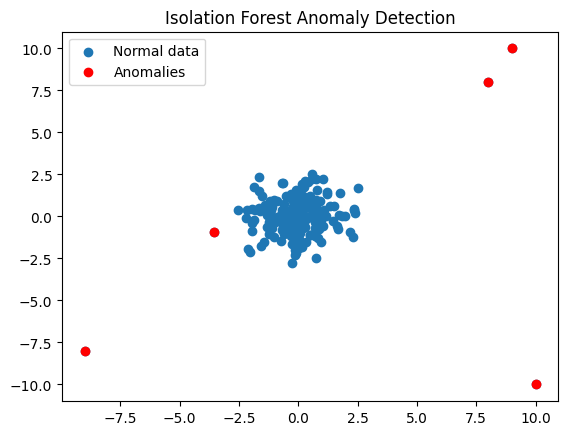

In [9]:
plt.scatter(X[:, 0], X[:, 1], label="Normal data")
plt.scatter(anomalies[:, 0], anomalies[:, 1], color="red", label="Anomalies")

plt.legend()
plt.title("Isolation Forest Anomaly Detection")
plt.show()